ACTIVITY RECOGNITION — ADAM-sense CNN3 Config
TensorFlow version: 2.13.0
GPU available: True

STEP 1: Loading Preprocessed Data
Training: (24020, 260, 6)
Test: (2230, 260, 6)

Activities:
  0: knuckles_cracking
  1: hand_tapping
  2: sitting
  3: standing
  4: smoking
  5: ear_rubbing
  6: hand_scratching
  7: nail_biting
  8: hair_pulling
  9: forehead_rubbing
  10: nape_rubbing

STEP 2: Building CNN3 Model (paper config)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv1D)              (None, 260, 128)          2432      
                                                                 
 pool1 (MaxPooling1D)        (None, 130, 128)          0         
                                                                 
 conv2 (Conv1D)              (None, 130, 128)          49280     
                                                                 
 pool2 (MaxPooling1D)  

2026-05-29 00:14:52.452979: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


601/601 [==============================] - ETA: 0s - loss: 1.3291 - accuracy: 0.5864

2026-05-29 00:15:00.335396: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


601/601 [==============================] - 9s 14ms/step - loss: 1.3291 - accuracy: 0.5864 - val_loss: 3.0180 - val_accuracy: 0.4475
Epoch 2/25
601/601 [==============================] - 8s 13ms/step - loss: 0.9980 - accuracy: 0.7270 - val_loss: 4.0397 - val_accuracy: 0.4122
Epoch 3/25
601/601 [==============================] - 8s 13ms/step - loss: 0.8895 - accuracy: 0.7710 - val_loss: 4.3295 - val_accuracy: 0.4652
Epoch 4/25
601/601 [==============================] - 8s 14ms/step - loss: 0.8921 - accuracy: 0.7886 - val_loss: 4.9358 - val_accuracy: 0.4473
Epoch 5/25
601/601 [==============================] - 8s 13ms/step - loss: 0.9665 - accuracy: 0.8015 - val_loss: 5.9782 - val_accuracy: 0.4650
Epoch 6/25
601/601 [==============================] - 8s 13ms/step - loss: 0.8801 - accuracy: 0.8217 - val_loss: 6.4773 - val_accuracy: 0.4917
Epoch 6: early stopping

Training complete!

STEP 4: Evaluating Model

Test Results:
  Loss: 1.1200
  Accuracy: 66.14%


2026-05-29 00:15:42.161442: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Classification Report:
                   precision    recall  f1-score   support

knuckles_cracking      0.867     0.986     0.923       212
     hand_tapping      0.951     1.000     0.975       156
          sitting      1.000     1.000     1.000       159
         standing      1.000     0.994     0.997       160
          smoking      0.667     0.015     0.030       264
      ear_rubbing      0.985     0.603     0.748       219
  hand_scratching      0.712     0.888     0.790       223
      nail_biting      0.574     0.564     0.569       165
     hair_pulling      0.285     0.540     0.373       235
 forehead_rubbing      0.435     0.874     0.581       214
     nape_rubbing      1.000     0.229     0.372       223

         accuracy                          0.661      2230
        macro avg      0.771     0.699     0.669      2230
     weighted avg      0.753     0.661     0.629      2230


STEP 5: Visualizing Results


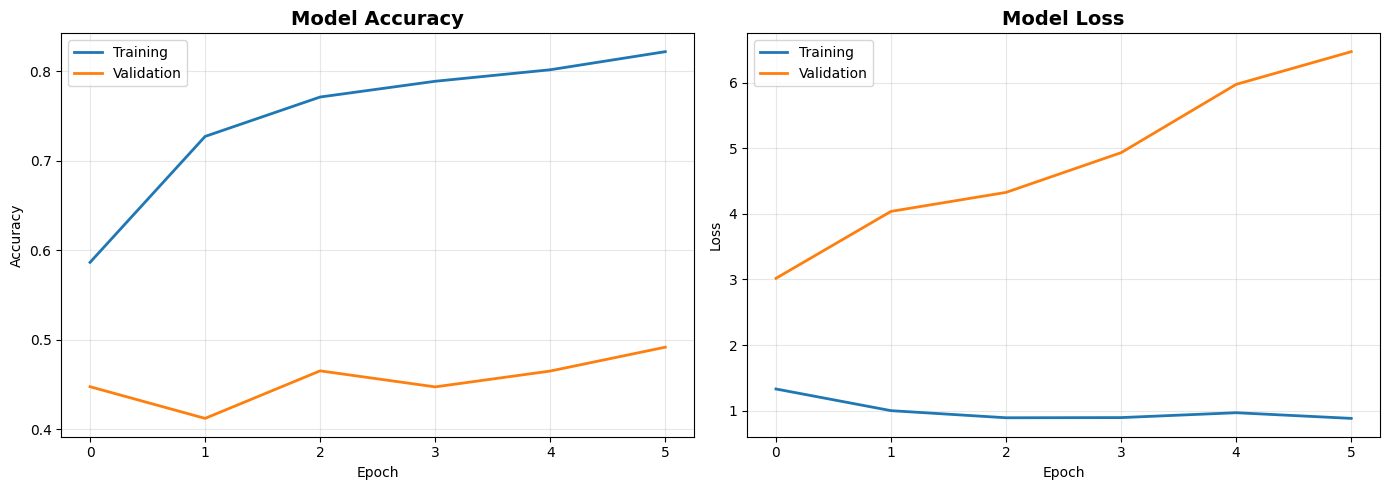

Saved: ../results/training_history.png


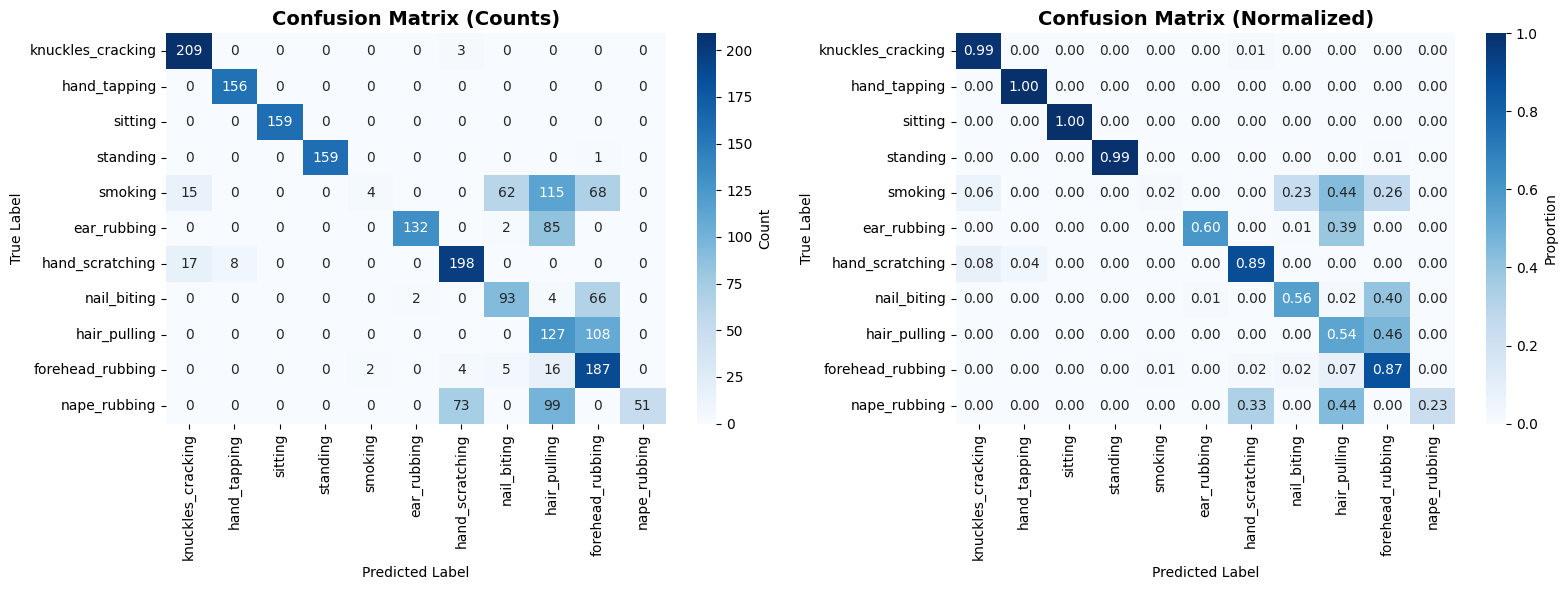

Saved: ../results/confusion_matrix.png

STEP 6: Saving Model
Saved: ../models/activity_model.h5
Saved: ../models/training_info.pkl

TRAINING COMPLETE!
  Test Accuracy: 66.14%
  Test Loss: 1.1200
  Parameters: 884,923
  Activities: 11
  Architecture: CNN3 (paper: 2×Conv128, F=3, DL=100, dropout=0.5)
  Window: 260 samples, leave-one-out (test user 3)
  Paper benchmark: 79.72% (CNN3, WS=260, wrist A+G)


/opt/homebrew/Caskroom/miniforge/base/envs/tinyml2/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("ACTIVITY RECOGNITION — ADAM-sense CNN3 Config")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# STEP 1: Load Preprocessed Data
print("\n" + "="*60)
print("STEP 1: Loading Preprocessed Data")
print("="*60)

data_dir = Path('../data/processed')

X_train = np.load(data_dir / 'X_train.npy')
y_train = np.load(data_dir / 'y_train.npy')
X_test = np.load(data_dir / 'X_test.npy')
y_test = np.load(data_dir / 'y_test.npy')

with open(data_dir / 'preprocessing_info.pkl', 'rb') as f:
    preprocessing_info = pickle.load(f)

label_to_activity = preprocessing_info['label_to_activity']
config = preprocessing_info['config']

print(f"Training: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"\nActivities:")
for label, activity in label_to_activity.items():
    print(f"  {label}: {activity}")

# STEP 2: Build CNN3 Model (paper config: 2 conv layers, K=128, F=3, L=2, DL=100)
print("\n" + "="*60)
print("STEP 2: Building CNN3 Model (paper config)")
print("="*60)

def build_model(input_shape, num_classes):
    """CNN3 from ADAM-sense paper: 2 conv layers K=128, F=3, L=2, DL=100, dropout=0.5"""
    model = models.Sequential([
        layers.Input(shape=input_shape, name='input'),
        
        # Conv block 1: K=128, F=3, S=1
        layers.Conv1D(filters=128, kernel_size=3, strides=1, activation='relu', padding='same', name='conv1'),
        layers.MaxPooling1D(pool_size=2, name='pool1'),
        
        # Conv block 2: K=128, F=3, S=1
        layers.Conv1D(filters=128, kernel_size=3, strides=1, activation='relu', padding='same', name='conv2'),
        layers.MaxPooling1D(pool_size=2, name='pool2'),
        
        # Flatten + Dense (DL=100)
        layers.Flatten(name='flatten'),
        layers.Dense(100, activation='relu', name='fc1'),
        layers.Dropout(0.5, name='dropout1'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2])  # (260, 6)
num_classes = len(label_to_activity)

model = build_model(input_shape, num_classes)

model.compile(
    optimizer=keras.optimizers.legacy.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

# STEP 3: Train Model (paper config: epochs 25, early stopping patience 5)
print("\n" + "="*60)
print("STEP 3: Training Model")
print("="*60)

EPOCHS = 25
BATCH_SIZE = 32

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
]

print(f"Training for up to {EPOCHS} epochs (early stopping patience=5)...")
print(f"Batch size: {BATCH_SIZE}")

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

# STEP 4: Evaluate Model
print("\n" + "="*60)
print("STEP 4: Evaluating Model")
print("="*60)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy*100:.2f}%")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[label_to_activity[i] for i in range(num_classes)],
    digits=3
))

# STEP 5: Visualize Results
print("\n" + "="*60)
print("STEP 5: Visualizing Results")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, weight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, weight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(results_dir / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/training_history.png")

cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_to_activity[i] for i in range(num_classes)],
            yticklabels=[label_to_activity[i] for i in range(num_classes)],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, weight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[label_to_activity[i] for i in range(num_classes)],
            yticklabels=[label_to_activity[i] for i in range(num_classes)],
            ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, weight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(results_dir / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/confusion_matrix.png")

# STEP 6: Save Model
print("\n" + "="*60)
print("STEP 6: Saving Model")
print("="*60)

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

model.save(models_dir / 'activity_model.h5')
print(f"Saved: {models_dir / 'activity_model.h5'}")

training_info = {
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'total_params': int(total_params),
    'epochs_trained': len(history.history['accuracy']),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'config': config,
    'label_to_activity': label_to_activity,
    'input_shape': input_shape,
    'num_classes': num_classes
}

with open(models_dir / 'training_info.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print(f"Saved: {models_dir / 'training_info.pkl'}")

# SUMMARY
print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"  Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Parameters: {total_params:,}")
print(f"  Activities: {num_classes}")
print(f"  Architecture: CNN3 (paper: 2×Conv128, F=3, DL=100, dropout=0.5)")
print(f"  Window: {input_shape[0]} samples, leave-one-out (test user 3)")
print(f"  Paper benchmark: 79.72% (CNN3, WS=260, wrist A+G)")